# Introduction to Scikit Learn: Classification

Here we look at performing a classification task with scikit. This task involves predicting whether or not someone survived on the Titanic based on their ticket information. This task is eerily easy for a machine learning model.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from ml_data_tools import make_train_test_split_dataframes

max_iterations = 1000

## Load the Titanic Data

Here with load the data with pandas. We apply our custom train / test split function to keep the data in a DataFrame.

In [2]:
# Load Data
titanic_df = pd.read_csv("./datasets/titanic/tested.csv")

# Clean Data
target_column = "Survived"
features_list = ["Pclass", "Age", "Sex", "Fare", "Survived"]
titanic_df = titanic_df[features_list].dropna()
titanic_df["Sex"] = titanic_df["Sex"].map({"male": 0, "female": 1})

# Train / test split using our custom function
x_train, x_test, y_train, y_test = make_train_test_split_dataframes(
    titanic_df, features_list, target_column, test_fraction=0.2
)

titanic_df.head()

,Pclass,Age,Sex,Fare,Survived,test flag
0,3,34.5,0,7.8292,0,0.0
1,3,47.0,1,7.0000,1,1.0
2,2,62.0,0,9.6875,0,0.0
3,3,27.0,0,8.6625,0,0.0
4,3,22.0,1,12.2875,1,0.0


## Build a Classifier

Here we build a classifier. We specify a modest number of hidden neurons to fit this relatively easy problem.

In [3]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

input_scaler = StandardScaler()
x_train_scaled = input_scaler.fit_transform(x_train)

number_of_features = len(features_list)
number_hidden = 20

mlp_structure = (number_hidden,)

mlp = MLPClassifier(
    hidden_layer_sizes=mlp_structure,
    max_iter=max_iterations,
    tol=1e-9,
    n_iter_no_change=10,
    activation="relu",
    solver="adam",
    random_state=123,
)

### Train the Classifier

Here we kick off a training run.

In [4]:
mlp.fit(x_train_scaled, y_train)

c:\Users\sanch\Repositories\lectures\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",123
,"tol tol: float, default=1e-4Tolerance for the optimization. When the loss or score is not improvingby at least ``tol`` for ``n_iter_no_change`` consecutive iterations,unless ``learning_rate`` is set to 'adaptive', convergence isconsidered to be reached and training stops.",1e-09
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5


### Test the Classifier

We test the classifier on a held out dataset.

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix

x_test_scaled = input_scaler.transform(x_test)
y_hat_test = mlp.predict(x_test_scaled)

accuracy = accuracy_score(y_hat_test, y_test)

print(f"Accuracy = {accuracy * 100}%")

Accuracy = 100.0%


### Visualize the Results

Here we see how to visualize the results as a confusion matrix with seaborn.

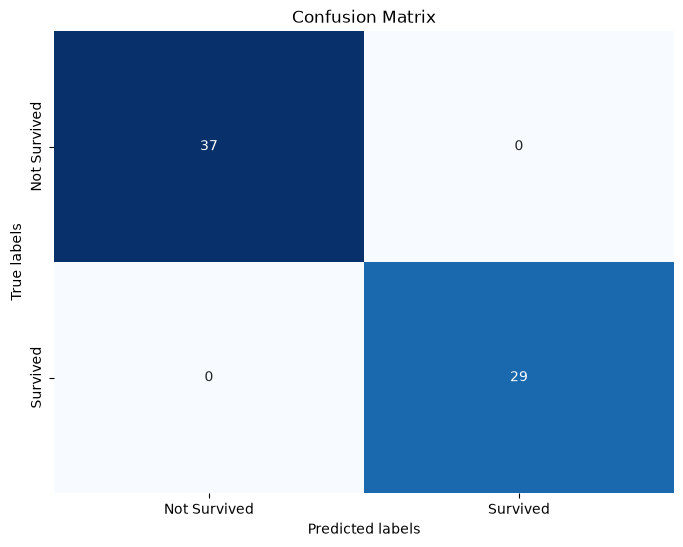

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

confusion_matrix = confusion_matrix(y_test, y_hat_test)

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"],
)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

### Visualize the Network Itself

We can see that this neural net is very small and still is able to learn the problem.

Layer   0:                           .  .  .  .  .                          
Layer   1:     .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .   
Layer   2:                                 .                                


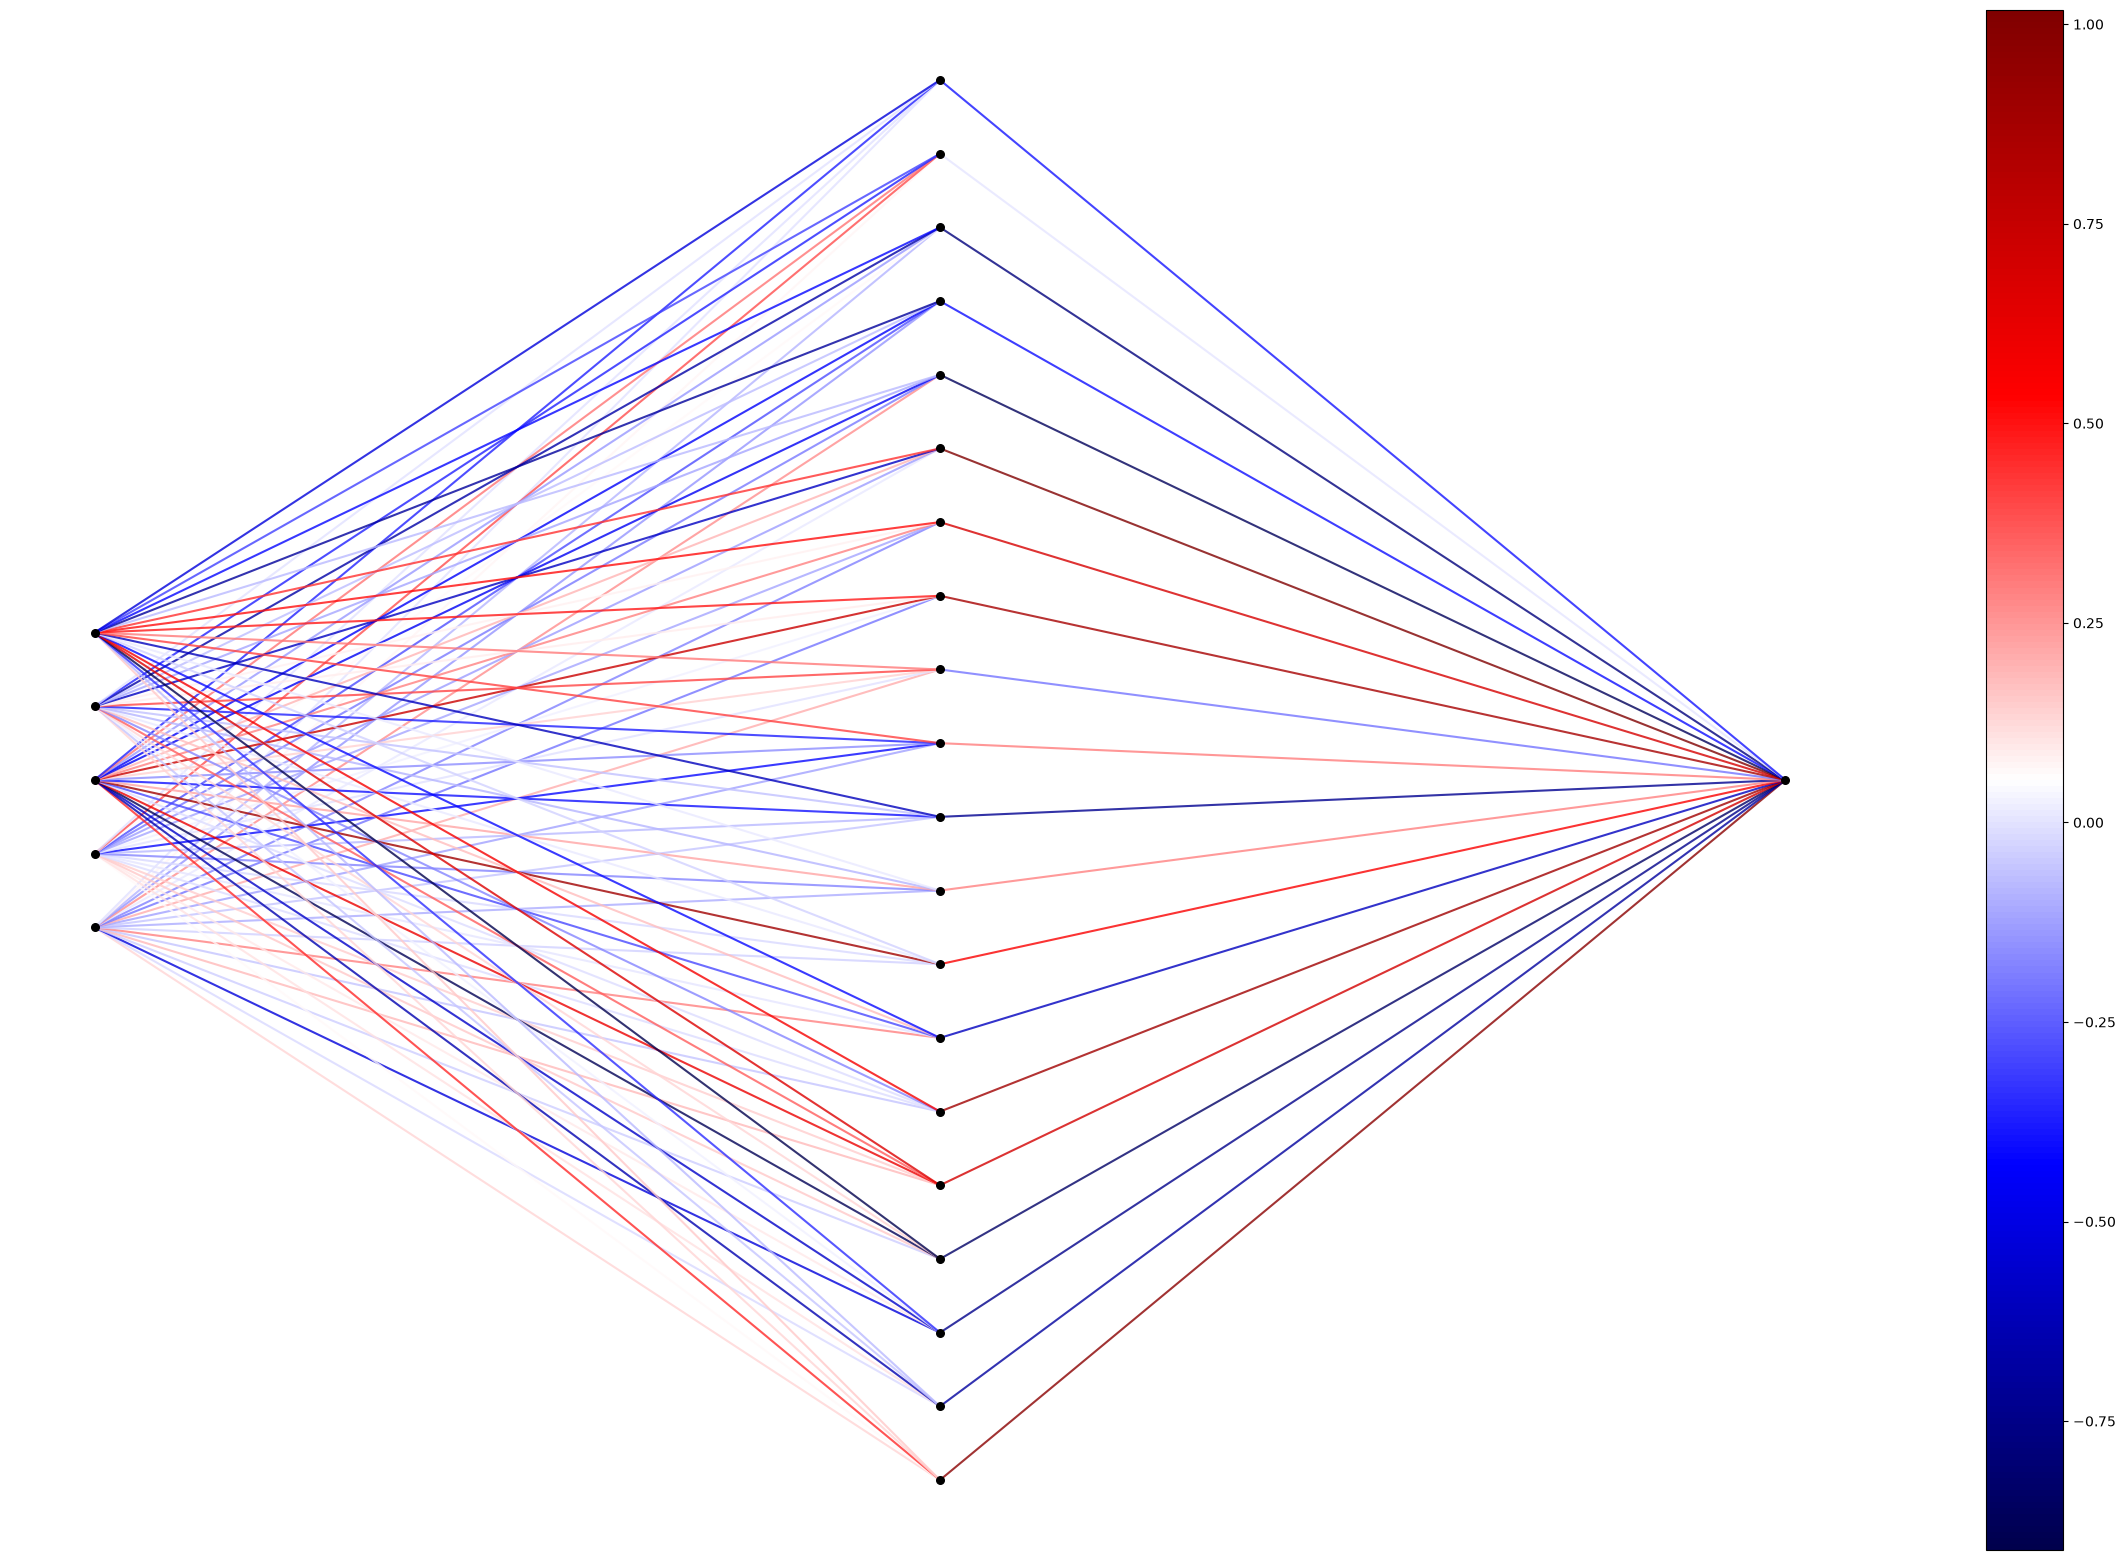

In [7]:
from mlp_visualization import display_mlp, print_ascii_mlp

print_ascii_mlp(mlp)

_ = display_mlp(
    mlp,
    linewidth=1.5,
    neuron_alpha=1,
    neuron_color="black",
    line_alpha=0.8,
    figure_width=30,
    figure_height=20,
    neuron_size=30,
    colormap_name="seismic",
)